In [12]:
# -----------------------------
# 0. INSTALLATION NOTE
# -----------------------------
# Run this once in a notebook cell if the packages are not installed:
# ! pip install pandas numpy matplotlib seaborn plotly squarify joypy scipy pyjanitor kaleido

In [13]:
# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import joypy
import plotly.graph_objects as go
import re

warnings.filterwarnings("ignore")

In [14]:
# -----------------------------
# 2. REPRODUCIBLE CONFIGURATION
# -----------------------------

# Reproducible paths
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "Data" / "Final_data_model.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Colors from the R project
COL_TEAL = "#69b3a2"
COL_RED = "#e74c3c"
COL_GREY = "lightgrey"

# Font fallback: Geologica if installed, otherwise DejaVu Sans
FONT_MAIN = "Geologica"

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [15]:
# -----------------------------
# 3. GLOBAL THEME
# -----------------------------

def set_unified_theme():
    """Apply a unified visual style similar to the R theme_unified()."""
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": [FONT_MAIN, "DejaVu Sans", "Arial"],
        "axes.titlesize": 22,
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.title_fontsize": 11,
        "legend.fontsize": 10,
        "figure.titlesize": 22,
    })


def save_fig(fig, filename):
    """Save matplotlib figures reproducibly into outputs/figures."""
    path = OUTPUT_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")


set_unified_theme()

In [16]:
# -----------------------------
# 4. DATA LOAD AND PREPROCESSING
# -----------------------------

def load_and_preprocess_data(path):
    df = pd.read_csv(path)

    def clean_column_name(name):
        name = str(name).strip().lower()
        name = re.sub(r"[()/%]", "", name)
        name = re.sub(r"[^a-z0-9]+", "_", name)
        name = re.sub(r"_+", "_", name)
        return name.strip("_")

    df.columns = [clean_column_name(col) for col in df.columns]
    
    # Rename selected columns for easier access
    rename_map = {
        "water_intake_liters": "water_l",
        "session_duration_hours": "duration_hrs",
        "difficulty_level": "difficulty_level",
        "calories_burned": "calories_burned",
        "workout_type": "workout_type",
        "avg_bpm": "avg_bpm",
        "resting_bpm": "resting_bpm",
        "max_bpm": "max_bpm",
        "fat_percentage": "fat_percentage",
        "gender": "gender",
        "weight_kg": "weight_kg",
        "workout_frequency_days_week": "workout_frequency_days_week",
    }

    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    # Ordered categorical variables
    df["difficulty_level"] = pd.Categorical(
        df["difficulty_level"],
        categories=["Beginner", "Intermediate", "Advanced"],
        ordered=True,
    )

    df["meal_type"] = pd.Categorical(
        df["meal_type"],
        categories=["Breakfast", "Lunch", "Dinner", "Snack"],
        ordered=True,
    )

    # Create caloric burn categories
    df["burn_category"] = pd.cut(
        df["calories_burned"],
        bins=[-np.inf, 400, 800, np.inf],
        labels=["Low Burn", "Med Burn", "High Burn"],
        right=False,
    )

    df["burn_category"] = pd.Categorical(
        df["burn_category"],
        categories=["Low Burn", "Med Burn", "High Burn"],
        ordered=True,
    )

    return df


df = load_and_preprocess_data(DATA_PATH)

print(df.shape)
df.head()

(20000, 55)


,age,gender,weight_kg,height_m,max_bpm,avg_bpm,resting_bpm,duration_hrs,calories_burned,workout_type,...,pct_carbs,protein_per_kg,pct_hrr,pct_maxhr,cal_balance,lean_mass_kg,expected_burn,burns_calories_per_30_min_bc,burns_calories_bin,burn_category
0,34.91,Male,65.592923,1.62,158.647531,135.542391,86.838582,0.810686,513.155296,Cardio,...,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Low,Med Burn
1,23.37,Female,56.410000,1.55,165.244978,116.702269,77.281148,1.270820,576.245857,Strength,...,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High,Med Burn
2,33.20,Female,59.141921,1.67,160.014254,161.811856,89.557526,0.607471,471.256240,HIIT,...,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High,Med Burn
3,38.69,Female,94.152458,1.70,189.348708,154.495497,48.857641,1.553248,1698.306387,Strength,...,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High,High Burn
4,45.09,Male,54.454370,1.88,180.432454,92.706098,38.240459,1.061695,313.271030,Yoga,...,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low,Low Burn


Saved: /Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 4/Reproducible_Research/ReproducibleResearch/outputs/figures/01_treemap_plate_under_microscope.png


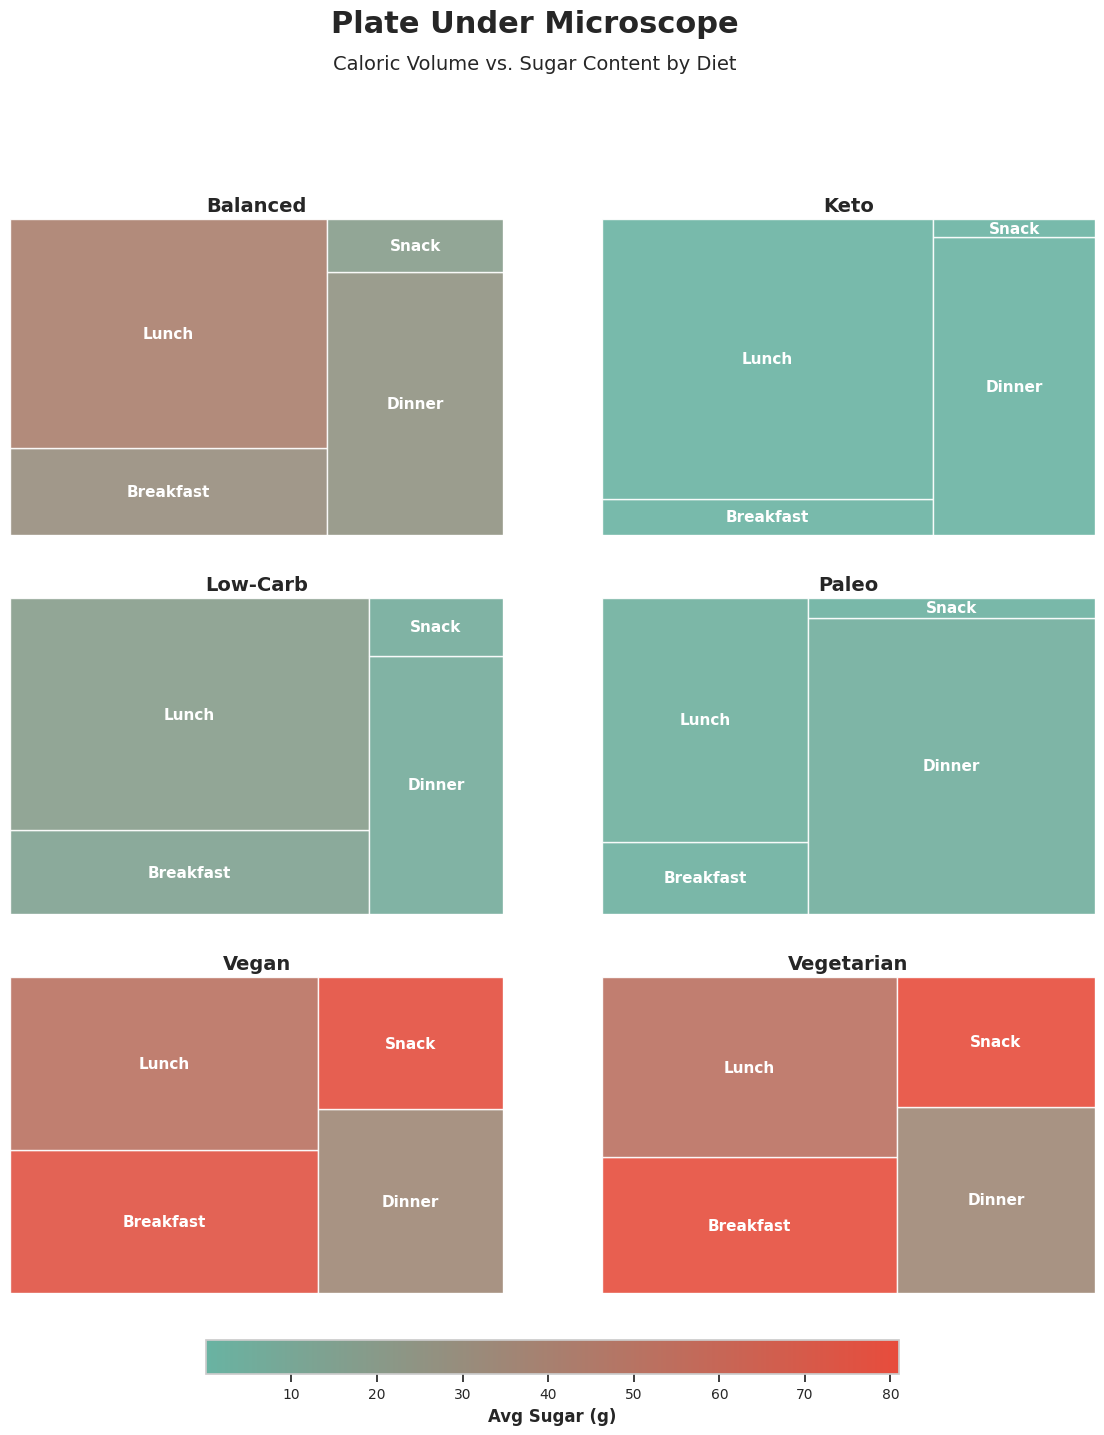

In [17]:
# ============================================================
# PLOT 1: TREEMAP — Plate Under Microscope
# ============================================================

tree_data = (
    df.groupby(["diet_type", "meal_type"], observed=True)
    .agg(
        total_calories=("calories", "sum"),
        avg_sugar=("sugar_g", "mean")
    )
    .reset_index()
)

diets = tree_data["diet_type"].dropna().unique()
n_diets = len(diets)
cols = 2
rows = int(np.ceil(n_diets / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = np.array(axes).reshape(-1)

norm = plt.Normalize(tree_data["avg_sugar"].min(), tree_data["avg_sugar"].max())
cmap = sns.color_palette("blend:#69b3a2,#e74c3c", as_cmap=True)

for ax, diet in zip(axes, diets):
    subset = tree_data[tree_data["diet_type"] == diet]
    colors = [cmap(norm(x)) for x in subset["avg_sugar"]]

    squarify.plot(
        sizes=subset["total_calories"],
        label=subset["meal_type"].astype(str),
        color=colors,
        alpha=0.9,
        ax=ax,
        text_kwargs={"color": "white", "weight": "bold", "fontsize": 11},
    )

    ax.set_title(str(diet), fontsize=14, weight="bold")
    ax.axis("off")

for ax in axes[len(diets):]:
    ax.axis("off")

fig.suptitle("Plate Under Microscope", weight="bold", y=1.02)
fig.text(
    0.5, 0.98,
    "Caloric Volume vs. Sugar Content by Diet",
    ha="center",
    fontsize=14,
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), orientation="horizontal", fraction=0.03, pad=0.04)
cbar.set_label("Avg Sugar (g)", weight="bold")

save_fig(fig, "01_treemap_plate_under_microscope.png")
plt.show()